In [1]:
import darshan as dardarbinks
import seaborn as sb
import pandas as pd
import darshan.backend.cffi_backend as backend

dardarbinks.enable_experimental()

from argparse import ArgumentParser
from darshan_helpers import load_dataframe
from darshan_helpers import METADATA_COLUMNS

In [2]:
import ipywidgets as widgets
from ipywidgets import interact, interactive
from IPython.display import display

special_groupings = [
    "operation_types",
    "posix_v_stdio"
]

def args(workdir, exp_type, exp_name, limit_cpu):
    return (workdir, exp_type, exp_name, limit_cpu)

arguments=interactive(args, workdir="../../data/exps", exp_type=["weak_scaling", "strong_scaling"], exp_name=["general"], limit_cpu=False, limit_runs=False, continuous_update=False)
display(arguments)

interactive(children=(Text(value='../../data/exps', description='workdir'), Dropdown(description='exp_type', o…

In [3]:
# load data
# print(arguments.result)
darshan_data = load_dataframe(arguments.result[0], arguments.result[1], arguments.result[2], arguments.result[3], modules=["POSIX", "STDIO"])
darshan_data = darshan_data.compute()
darshan_data

Parameters:
workdir:  ../../data/exps
experiment_type:  weak_scaling
experiment_name:  general
limit_cpu:  False
modules:  ['POSIX', 'STDIO']
../../data/exps/weak_scaling/general/1/apptainer/false/1/112512_python_id1838774-1838774_3-27-37814-1360206179109989337_1.darshan
../../data/exps/weak_scaling/general/1/apptainer/false/1/112512_python_id1838774-1839403_3-27-38269-2321707756565177321_1.darshan
../../data/exps/weak_scaling/general/1/apptainer/false/1/112512_python_id1838774-1839404_3-27-38269-10382837159702243456_1.darshan
../../data/exps/weak_scaling/general/1/apptainer/false/1/112512_python_id1838774-1839405_3-27-38269-1532692944162590539_1.darshan
../../data/exps/weak_scaling/general/1/apptainer/false/2/112512_python_id1846566-1846566_3-27-39380-1234919274341847134_1.darshan
../../data/exps/weak_scaling/general/1/apptainer/false/2/112512_python_id1846566-1846678_3-27-39511-3944443768296607840_1.darshan
../../data/exps/weak_scaling/general/1/apptainer/false/2/112512_python_id1846

/home/wkwiecinski/.ath_analysis/lib/python3.10/site-packages/dask/dataframe/dask_expr/_expr.py:1957: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = val


,file_name,id,process,POSIX_OPENS,POSIX_FILENOS,POSIX_DUPS,POSIX_READS,POSIX_WRITES,POSIX_SEEKS,POSIX_STATS,...,STDIO_F_FASTEST_RANK_TIME,STDIO_F_SLOWEST_RANK_TIME,STDIO_F_VARIANCE_RANK_TIME,STDIO_F_VARIANCE_RANK_BYTES,time (s),max_events,nprocs,container,run,basename
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1.512558e+15,main,2.0,2.0,0.0,3.0,0.0,1.0,0.0,...,NaN,NaN,NaN,NaN,1516.0,1000,1,apptainer,1,libPersistentDataModelDict.so
0,/tmp/wkwiecin/experiment/weak_scaling/general/...,3.077787e+18,worker_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1125.0,1000,1,apptainer,5,PoolFileCatalog.xml
0,/tmp/wkwiecin/experiment/weak_scaling/general/...,1.198194e+17,shared_writer,2.0,0.0,0.0,44.0,15000.0,15044.0,0.0,...,NaN,NaN,NaN,NaN,1127.0,1000,1,apptainer,5,DAOD_PHYSLITE.pool.root.1
0,/tmp/wkwiecin/experiment/weak_scaling/general/...,1.545303e+16,evt_counter,3.0,0.0,2.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,3.0,1000,1,apptainer,2,AthenaMP.log
0,/tmp/wkwiecin/experiment/weak_scaling/general/...,2.846510e+18,worker_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1033.0,1000,1,apptainer,2,athenamp_eventorders.txt.Derivation
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3053,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,1.843823e+19,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,NaN,NaN,1318.0,8000,8,shifter,3,isolation_ptcorrections_rel20_2.root
3053,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,1.843823e+19,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,NaN,NaN,2067.0,8000,8,shifter,1,isolation_ptcorrections_rel20_2.root
3053,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,1.843823e+19,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,NaN,NaN,1387.0,8000,8,shifter,5,isolation_ptcorrections_rel20_2.root
3053,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,1.843823e+19,main,2.0,0.0,0.0,378.0,0.0,378.0,0.0,...,NaN,NaN,NaN,NaN,1314.0,8000,8,shifter,2,isolation_ptcorrections_rel20_2.root


In [10]:
import seaborn as sb
module_operations = ["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS"]
ext_df = darshan_data[METADATA_COLUMNS + module_operations].dropna()
ext_df["file_extension"] = ext_df["basename"].str.split(".", n=1).str[1]
ext_df = ext_df[ext_df["run"] == "1"]

ext_df

,file_name,id,process,basename,max_events,nprocs,container,run,POSIX_OPENS,POSIX_READS,POSIX_WRITES,POSIX_SEEKS,POSIX_STATS,POSIX_MMAPS,POSIX_FSYNCS,POSIX_FDSYNCS,file_extension
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1.512558e+15,main,libPersistentDataModelDict.so,1000,1,apptainer,1,2.0,3.0,0.0,1.0,0.0,-1.0,0.0,0.0,so
0,/tmp/wkwiecin/experiment/weak_scaling/general/...,1.138886e+18,shared_writer,FileManagerLog,1000,1,apptainer,1,1.0,2348.0,1.0,0.0,0.0,-1.0,0.0,0.0,NaN
0,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/sw/...,4.894134e+15,worker_0,TVector3.h,1000,1,apptainer,1,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,h
0,/cvmfs/atlas.cern.ch/repo/sw/database/GroupDat...,7.442843e+18,evt_counter,e1hg_systematics_histos.root,1000,1,apptainer,1,6.0,0.0,0.0,3.0,0.0,-1.0,0.0,0.0,root
1,/tmp/wkwiecin/experiment/weak_scaling/general/...,4.580762e+18,shared_writer,DAOD_PHYSLITE.pool.root.1,1000,1,apptainer,1,2.0,44.0,15000.0,15044.0,0.0,-1.0,13.0,0.0,pool.root.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1.840621e+19,main,CaloExtensionBuilderAlgCfg.py,8000,8,shifter,1,1.0,2.0,0.0,2.0,0.0,-1.0,0.0,0.0,py
3050,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1.842001e+19,main,HLTMenuConfig.py,8000,8,shifter,1,1.0,2.0,0.0,2.0,0.0,-1.0,0.0,0.0,py
3051,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1.842487e+19,main,TrigConfigSvcCfg.py,8000,8,shifter,1,1.0,2.0,0.0,2.0,0.0,-1.0,0.0,0.0,py
3052,/cvmfs/atlas.cern.ch/repo/sw/software/25.0/Ath...,1.843315e+19,main,libxAODHIEventDict.so,8000,8,shifter,1,2.0,2.0,0.0,0.0,0.0,-1.0,0.0,0.0,so


                  POSIX_WRITES  POSIX_SEQ_WRITES  POSIX_CONSEC_WRITES  \
nprocs container                                                        
1      apptainer       15608.0           15419.0              15360.0   
       none            15608.0           15419.0              15360.0   
       podman          15608.0           15419.0              15360.0   
       shifter         15608.0           15419.0              15360.0   
2      apptainer       22601.0           22250.0              22150.0   
       none            22605.0           22253.0              22152.0   
       podman          22612.0           22262.0              22162.0   
       shifter         22612.0           22259.0              22158.0   
4      apptainer       36800.0           35418.0              35223.0   
       none            36778.0           35700.0              35487.0   
       podman          36781.0           35351.0              35147.0   
       shifter         36794.0           35421.0   

/tmp/ipykernel_282804/493816120.py:8: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  seq_df = seq_df.groupby(["nprocs", "container"]).agg({"POSIX_WRITES": "sum", "POSIX_SEQ_WRITES": "sum",  "POSIX_CONSEC_WRITES": sum, "POSIX_READS": "sum", "POSIX_SEQ_READS": "sum", "POSIX_CONSEC_READS": "sum"})


<Axes: xlabel='nprocs,container'>

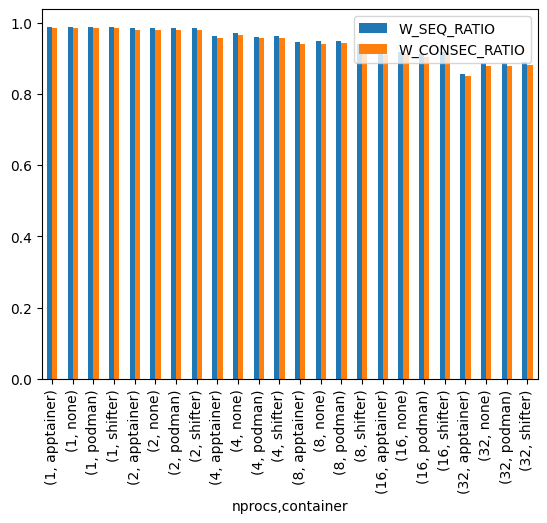

In [24]:
import seaborn as sb

module_operations = ["POSIX_READS", "POSIX_WRITES", "POSIX_CONSEC_READS", "POSIX_CONSEC_WRITES", "POSIX_SEQ_READS", "POSIX_SEQ_WRITES"]
seq_df = darshan_data[["file_name", "id", "process", "basename", "max_events", "nprocs", "container", "run"] + module_operations].dropna()
# seq_df["nprocs"] = pd.to_numeric(seq_df["nprocs"])
seq_df = seq_df[seq_df["nprocs"] != 64]
seq_df = seq_df[seq_df["run"] == "1"]
seq_df = seq_df.groupby(["nprocs", "container"]).agg({"POSIX_WRITES": "sum", "POSIX_SEQ_WRITES": "sum",  "POSIX_CONSEC_WRITES": sum, "POSIX_READS": "sum", "POSIX_SEQ_READS": "sum", "POSIX_CONSEC_READS": "sum"})
seq_df["W_SEQ_RATIO"] = seq_df["POSIX_SEQ_WRITES"] / seq_df["POSIX_WRITES"]
seq_df["W_CONSEC_RATIO"] = seq_df["POSIX_CONSEC_WRITES"] / seq_df["POSIX_WRITES"]
seq_df["R_SEQ_RATIO"] = seq_df["POSIX_SEQ_READS"] / seq_df["POSIX_READS"]
seq_df["R_CONSEC_RATIO"] = seq_df["POSIX_CONSEC_READS"] / seq_df["POSIX_READS"]

print(seq_df)

# seq_df.plot(kind="bar", y=["POSIX_SEQ_WRITES", "POSIX_CONSEC_WRITES", "POSIX_WRITES"], stacked=True)
# sb.boxenplot(seq_df, x="nprocs", y="", hue="container")
seq_df.plot(kind="bar", y=["W_SEQ_RATIO", "W_CONSEC_RATIO"], stacked=False)

/tmp/ipykernel_83514/401678488.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nprocs"] = pd.to_numeric(df["nprocs"])
/tmp/ipykernel_83514/401678488.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["POSIX_TOTAL"] = df[["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS",
/tmp/ipykernel_83514/401678488.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

<Axes: xlabel='nprocs', ylabel='POSIX_TOTAL'>

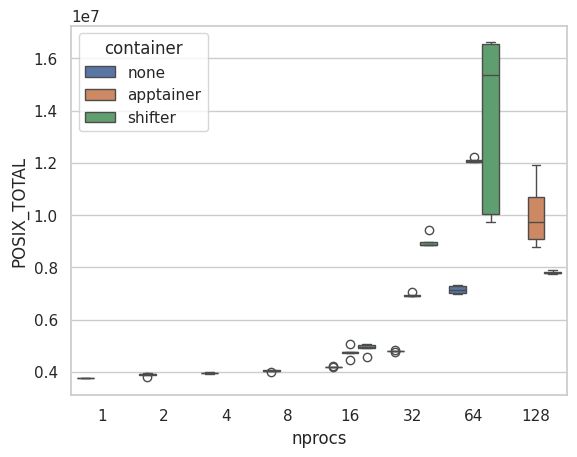

In [5]:
import seaborn as sb

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]
df = darshan_data[METADATA_COLUMNS + module_operations]

df["nprocs"] = pd.to_numeric(df["nprocs"])
df["POSIX_TOTAL"] = df[["POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_MMAPS", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["STDIO_TOTAL"] = df[["STDIO_OPENS", "STDIO_READS",
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"]].sum(axis=1, numeric_only=True)
df = df[METADATA_COLUMNS + ["POSIX_TOTAL", "STDIO_TOTAL"]]
df = df.sort_values(by=["nprocs"])
df = df.groupby(by=["nprocs", "run", "container"]).agg({"POSIX_TOTAL": "sum", "STDIO_TOTAL": "sum"}).reset_index()
df

sb.set_theme(style="whitegrid")
sb.boxplot(data=df, x="nprocs", y="POSIX_TOTAL", hue="container")

In [6]:
# TODO:: include stdio
# MMAPS removed due to bad value (-1), not included in data or metadata ops anyway

module_operations = [
    "POSIX_OPENS", "POSIX_READS", "POSIX_WRITES", "POSIX_SEEKS", "POSIX_STATS", 
    "POSIX_FSYNCS", "POSIX_FDSYNCS", "STDIO_OPENS", "STDIO_READS", 
    "STDIO_WRITES", "STDIO_SEEKS", "STDIO_FLUSHES"
]

df = darshan_data[METADATA_COLUMNS + module_operations]
df["nprocs"] = pd.to_numeric(df["nprocs"])
df["POSIX_METADATA_OPS"] = df[["POSIX_OPENS", "POSIX_SEEKS", "POSIX_STATS"]].sum(axis=1, numeric_only=True)
df["POSIX_DATA_OPS"] = df[["POSIX_READS", "POSIX_WRITES", "POSIX_FSYNCS", "POSIX_FDSYNCS"]].sum(axis=1, numeric_only=True)
df["POSIX_TOTAL"] = df[["POSIX_METADATA_OPS", "POSIX_DATA_OPS"]].sum(axis=1, numeric_only=True)
df["STDIO_METADATA_OPS"] = df[["STDIO_OPENS", "STDIO_SEEKS"]].sum(axis=1, numeric_only=True)
df["STDIO_DATA_OPS"] = df[["STDIO_READS", "STDIO_WRITES"]].sum(axis=1, numeric_only=True)
df["STDIO_TOTAL"] = df[["STDIO_METADATA_OPS", "STDIO_DATA_OPS"]].sum(axis=1, numeric_only=True)
df = df.groupby(by=["nprocs", "run", "container", "file_name"]).agg({
    "process": "unique",
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "POSIX_TOTAL": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum",
    "STDIO_TOTAL": "sum"
}).reset_index()
df["access_type"] = df["process"].str.len() == df["nprocs"] + 3
df["access_type"] = df["access_type"].map({True: "global", False: "local"}) # all processes accessed a file
df = df.groupby(by=["nprocs", "run", "container", "access_type"]).agg({
    "POSIX_METADATA_OPS": "sum",
    "POSIX_DATA_OPS": "sum",
    "POSIX_TOTAL": "sum",
    "STDIO_METADATA_OPS": "sum",
    "STDIO_DATA_OPS": "sum",
    "STDIO_TOTAL": "sum"
})
df = df.groupby(by=["nprocs", "container", "access_type"]).agg({
    "POSIX_METADATA_OPS": "mean",
    "POSIX_DATA_OPS": "mean",
    "POSIX_TOTAL": "mean",
    "STDIO_METADATA_OPS": "mean",
    "STDIO_DATA_OPS": "mean",
    "STDIO_TOTAL": "mean"
}).reset_index()
df["GLOBAL_POSIX_METADATA_OPS"] = df.apply(lambda row: row["POSIX_METADATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["GLOBAL_POSIX_DATA_OPS"] = df.apply(lambda row: row["POSIX_DATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["LOCAL_POSIX_METADATA_OPS"] = df.apply(lambda row: row["POSIX_METADATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["LOCAL_POSIX_DATA_OPS"] = df.apply(lambda row: row["POSIX_DATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["GLOBAL_STDIO_METADATA_OPS"] = df.apply(lambda row: row["STDIO_METADATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["GLOBAL_STDIO_DATA_OPS"] = df.apply(lambda row: row["STDIO_DATA_OPS"] if row["access_type"] == "global" else 0, axis=1)
df["LOCAL_STDIO_METADATA_OPS"] = df.apply(lambda row: row["STDIO_METADATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df["LOCAL_STDIO_DATA_OPS"] = df.apply(lambda row: row["STDIO_DATA_OPS"] if row["access_type"] == "local" else 0, axis=1)
df.drop(columns=["POSIX_METADATA_OPS", "POSIX_DATA_OPS", "POSIX_TOTAL", "STDIO_METADATA_OPS", "STDIO_DATA_OPS", "STDIO_TOTAL", "access_type"], inplace=True)
# df["TOTAL"] = df.groupby(by=["nprocs", "container", "access_type"])["POSIX_TOTAL"].sum()
df = df.groupby(by=["nprocs", "container"]).agg({
    "GLOBAL_POSIX_METADATA_OPS": "sum",
    "GLOBAL_POSIX_DATA_OPS": "sum",
    "LOCAL_POSIX_METADATA_OPS": "sum",
    "LOCAL_POSIX_DATA_OPS": "sum",
    "GLOBAL_STDIO_METADATA_OPS": "sum",
    "GLOBAL_STDIO_DATA_OPS": "sum",
    "LOCAL_STDIO_METADATA_OPS": "sum",
    "LOCAL_STDIO_DATA_OPS": "sum"
})
df["TOTAL_POSIX_OPS"] = df["GLOBAL_POSIX_METADATA_OPS"] + df["GLOBAL_POSIX_DATA_OPS"] + df["LOCAL_POSIX_METADATA_OPS"] + df["LOCAL_POSIX_DATA_OPS"]
df["TOTAL_STDIO_OPS"] = df["GLOBAL_STDIO_METADATA_OPS"] + df["GLOBAL_STDIO_DATA_OPS"] + df["LOCAL_STDIO_METADATA_OPS"] + df["LOCAL_STDIO_DATA_OPS"]

/tmp/ipykernel_83514/632936431.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["nprocs"] = pd.to_numeric(df["nprocs"])
/tmp/ipykernel_83514/632936431.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["POSIX_METADATA_OPS"] = df[["POSIX_OPENS", "POSIX_SEEKS", "POSIX_STATS"]].sum(axis=1, numeric_only=True)
/tmp/ipykernel_83514/632936431.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

<Axes: xlabel='nprocs,container'>

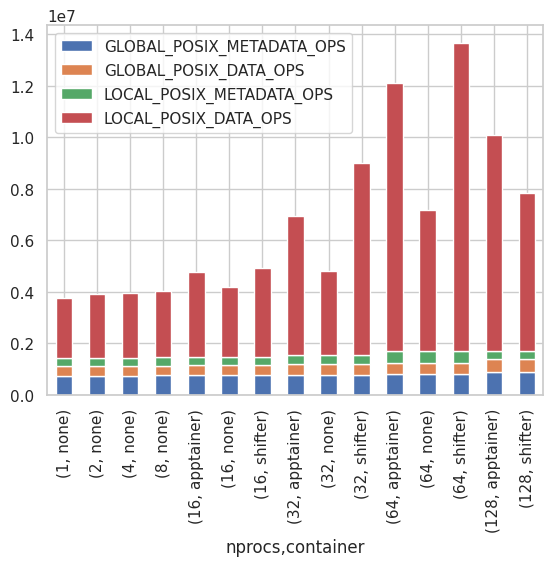

In [7]:
import seaborn as sb
df.plot(kind="bar", y=["GLOBAL_POSIX_METADATA_OPS", "GLOBAL_POSIX_DATA_OPS", "LOCAL_POSIX_METADATA_OPS", "LOCAL_POSIX_DATA_OPS"], stacked=True)

<Axes: xlabel='nprocs,container'>

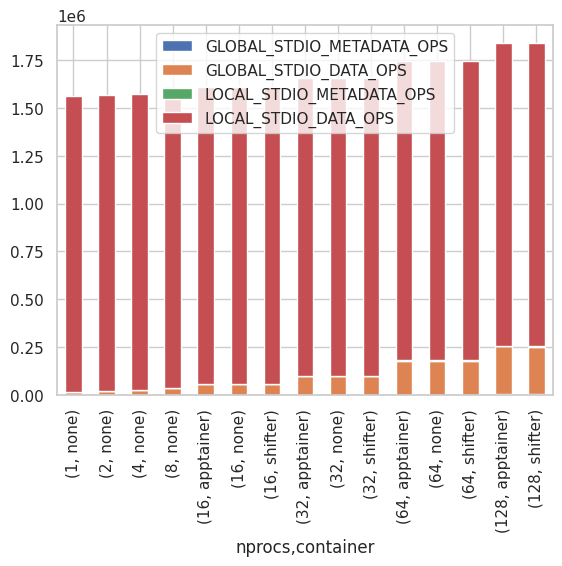

In [8]:
import seaborn as sb
df.plot(kind="bar", y=["GLOBAL_STDIO_METADATA_OPS", "GLOBAL_STDIO_DATA_OPS", "LOCAL_STDIO_METADATA_OPS", "LOCAL_STDIO_DATA_OPS"], stacked=True)

     nprocs  container      process run  POSIX_READS  POSIX_WRITES
114      16  apptainer  evt_counter   1       2508.0          34.0
305      16    shifter  evt_counter   2       2509.0          34.0
304      16    shifter  evt_counter   1       2507.0          34.0
308      16    shifter  evt_counter   5       2504.0          34.0
306      16    shifter  evt_counter   3       2508.0          34.0
..      ...        ...          ...  ..          ...           ...
261      16       none    worker_15   3     171876.0          52.0
262      16       none    worker_15   4     177653.0          57.0
263      16       none    worker_15   5     176107.0          57.0
354      16    shifter    worker_15   1     228581.0          55.0
164      16  apptainer    worker_15   1     192961.0          56.0

[285 rows x 6 columns]


/tmp/ipykernel_83514/2857944604.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=90)


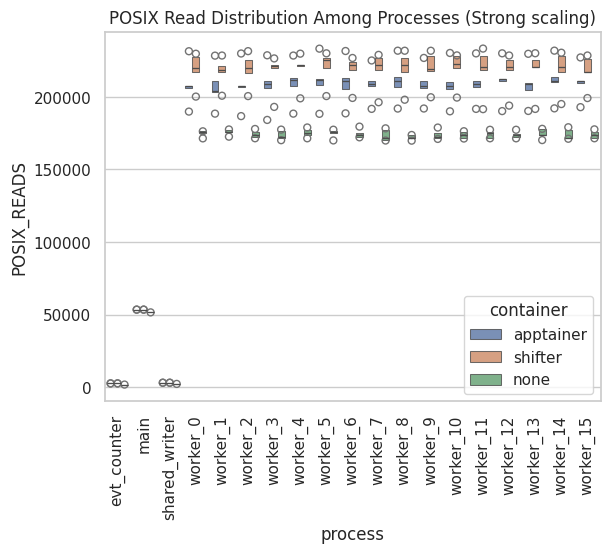

/tmp/ipykernel_83514/2857944604.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot2.set_xticklabels(plot2.get_xticklabels(), rotation=90)


     nprocs  container        process run  POSIX_READS  POSIX_WRITES
222      16       none  shared_writer   4       2152.0      274169.0
220      16       none  shared_writer   2       2150.0      274188.0
318      16    shifter  shared_writer   5       2965.0      265427.0
317      16    shifter  shared_writer   4       2968.0      265439.0
315      16    shifter  shared_writer   2       2970.0      269788.0
314      16    shifter  shared_writer   1       2968.0      265423.0
219      16       none  shared_writer   1       2152.0      265447.0
221      16       none  shared_writer   3       2152.0      274200.0
223      16       none  shared_writer   5       2151.0      274142.0
316      16    shifter  shared_writer   3       2969.0      274422.0
124      16  apptainer  shared_writer   1       2969.0      266865.0
125      16  apptainer  shared_writer   2       2965.0      266919.0
126      16  apptainer  shared_writer   3       2968.0      269600.0
127      16  apptainer  shared_wri

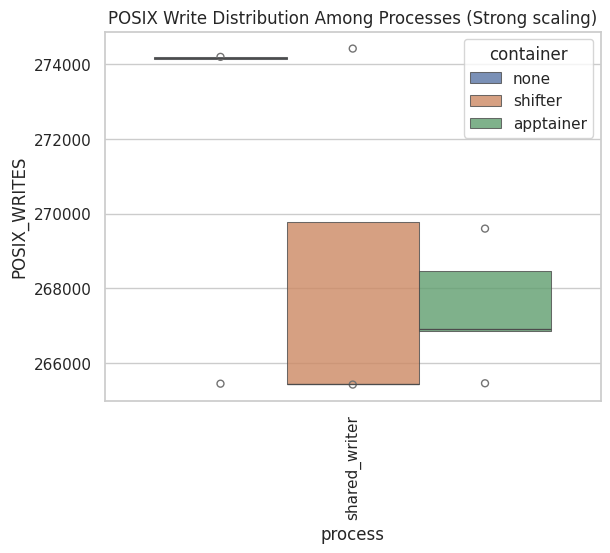

In [16]:
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np
import re
from natsort import natsort_keygen
# from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

GROUPINGS = {
    "evt_counter": "evt_counter",
    "main": "main",
    "shared_writer": "shared_writer",
}

def natural_sort_key(s):
    """Convert string into a list of str and int chunks for natural sorting."""
    return [int(c) if c.isdigit() else c.lower() for c in re.split(r'(\d+)', s)]

# find the distribution of reads and writes among processes
distribution_df = darshan_data[METADATA_COLUMNS + ["POSIX_READS", "POSIX_WRITES"]]
distribution_df = distribution_df.drop(columns=["id", "max_events", "limit_cpu"])
# distribution_df["group"] = distribution_df["process"].map(lambda x: GROUPINGS.get(x, "worker"))

distribution_df = distribution_df.groupby(by=["nprocs", "container", "process", "run"]).sum(numeric_only=True).reset_index()
# distribution_df = distribution_df.groupby(by=["nprocs", "container", "process"]).agg({"POSIX_READS": "mean", "POSIX_WRITES": "mean"}).reset_index()
# distribution_df

distribution_df["process"] = distribution_df["process"].astype(str)
distribution_df = distribution_df[distribution_df["nprocs"] == 16]
# distribution_df = distribution_df[distribution_df["container"] == "podman"]

distribution_df.sort_values(by="process", inplace=True, key=natsort_keygen())

print(distribution_df)

# sn.set_theme(style='whitegrid')
# palette = sn.color_palette('tab10')
# color1, color2 = palette[0], palette[1]
# fig, axs = plt.subplots(1,2)

plot = sn.boxenplot(data=distribution_df, x="process", y="POSIX_READS", hue="container", alpha=0.8)
plot.set_xticklabels(plot.get_xticklabels(), rotation=90)
plt.title(f'POSIX Read Distribution Among Processes ({" ".join(arguments.result[1].split("_")).capitalize()})')
plt.show()

print(distribution_df[distribution_df["process"] == "shared_writer"])

plot2 = sn.boxenplot(data=distribution_df[distribution_df["process"] == "shared_writer"], x="process", y="POSIX_WRITES", hue="container", alpha=0.8)
plot2.set_xticklabels(plot2.get_xticklabels(), rotation=90)
plt.title(f'POSIX Write Distribution Among Processes ({" ".join(arguments.result[1].split("_")).capitalize()})')
plt.show()
# fig, ax1 = plt.subplots(figsize=(9, 5))
# ax2 = ax1.twinx()

# # Compute bar positions manually so the two sets don't overlap
# n = len(distribution_df)
# x = np.arange(n)
# width = 0.35

# # --- Left Y-axis: first bar plot ---
# ax1.bar(x - width / 2, distribution_df['POSIX_READS'], width=width, color=color1, alpha=0.8, label='POSIX_READS')
# ax1.set_ylabel('POSIX_READS', color=color1)
# ax1.tick_params(axis='y', labelcolor=color1)
# ax1.tick_params(axis='x', rotation=90)
# ax1.set_xticks(x)
# ax1.set_xticklabels(distribution_df['process'])
# ax1.set_xlabel('Process')

# # --- Right Y-axis: second bar plot ---
# ax2.bar(x + width / 2, distribution_df['POSIX_WRITES'], width=width, color=color2, alpha=0.8, label='POSIX_WRITES')
# ax2.set_ylabel('POSIX_WRITES', color=color2)
# ax2.tick_params(axis='y', labelcolor=color2)

# # --- Combined legend ---
# handles = [
#     plt.Rectangle((0, 0), 1, 1, color=color1, alpha=0.8),
#     plt.Rectangle((0, 0), 1, 1, color=color2, alpha=0.8)
# ]
# ax1.legend(handles, ['POSIX_READS', 'POSIX_WRITES'], loc='upper left')

# fig.tight_layout()
# plt.savefig('dual_axis_two_bars.png', dpi=150)
# plt.show()
# fig
# plt.show(plot)
# plt.show(plot2)

In [9]:
# darshan_data[(darshan_data["container"] == "shifter")]["nprocs"].unique()
darshan_data["limit_cpu"].unique()

array([ True])

In [ ]:
# check sequential IO